In [1]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
benzeno = pd.read_csv('benzeno.csv')

In [3]:
benzeno

,Run,Conc.O,Temp,Rate
0,1,134.5,623,218
1,2,108.0,623,189
2,3,68.6,623,192
3,4,49.5,623,174
4,5,41.7,623,152
5,6,29.4,623,139
6,7,22.5,623,118
7,8,17.2,623,120
8,9,17.0,623,122
9,10,22.8,623,132


<Axes: >

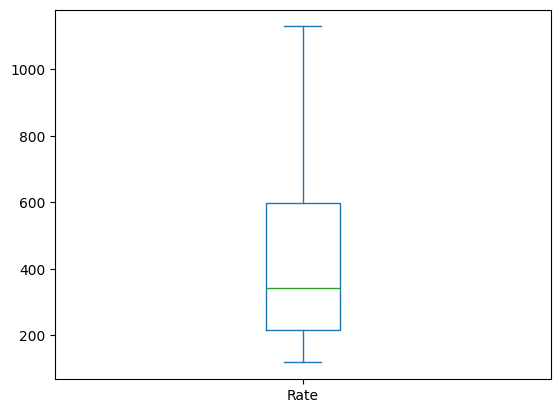

In [4]:
benzeno['Rate'].plot.box()

1) SEPARAR OS DADOS

In [5]:
benzeno_train, benzeno_test = train_test_split(benzeno, test_size=13, random_state=42)

print(benzeno_train.shape, benzeno_test.shape)

(35, 4) (13, 4)


In [12]:
x_train, x_test = sm.add_constant(benzeno_train[['Conc.O', 'Temp']]), sm.add_constant(benzeno_test[['Conc.O', 'Temp']])
y_train, y_test = benzeno_train['Rate'], benzeno_test['Rate']

In [13]:
benzeno_train.columns

Index(['Run', 'Conc.O', 'Temp', 'Rate'], dtype='str')

RATE = TARGET

2) REALIZAR AJUSTE

In [15]:
olls = sm.OLS(y_train, x_train).fit()
print(olls.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rate   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     123.3
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           9.20e-16
Time:                        12:17:56   Log-Likelihood:                -208.17
No. Observations:                  35   AIC:                             422.3
Df Residuals:                      32   BIC:                             427.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7075.8499    544.109    -13.004      0.0

In [16]:
olls.params


const    -7075.849914
Conc.O       2.671014
Temp        11.280515
dtype: float64

In [17]:
benzeno_test

,Run,Conc.O,Temp,Rate
27,28,30.0,648,294
40,47,11.2,673,373
26,27,29.5,648,295
43,50,108.2,673,724
24,25,55.2,648,338
37,44,47.2,673,649
12,13,119.7,623,216
19,20,140.0,648,493
4,5,41.7,623,152
25,26,55.4,648,351


In [18]:
predictions = olls.predict(x_test)

In [19]:
mse = mean_squared_error(y_test, predictions)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 7618.80039377101


In [20]:
naive = [benzeno['Rate'].mean()] * len(y_test)
mse_naive = mean_squared_error(y_test, naive)
print(f'Mean Squared Error (Naive): {mse_naive}')

Mean Squared Error (Naive): 41856.8586071047


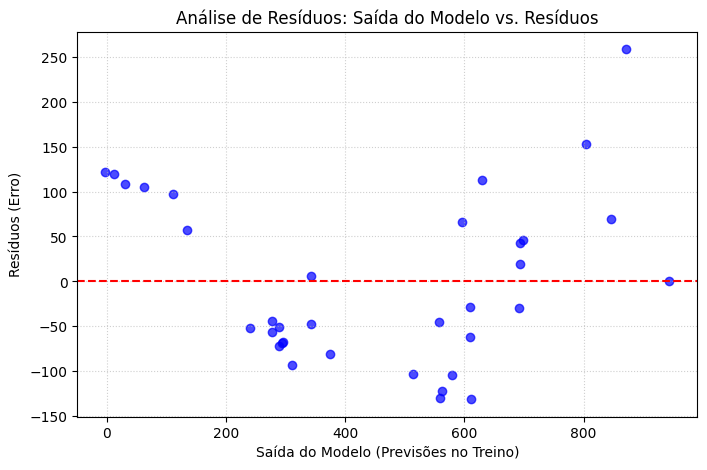

In [21]:
# 1. Extrair previsões (fitted values) e resíduos dos dados de treino
previsoes_treino = olls.fittedvalues
residuos = olls.resid

# 2. Criar o gráfico de dispersão (Scatterplot)
plt.figure(figsize=(8, 5))
plt.scatter(previsoes_treino, residuos, alpha=0.7, color='blue')
plt.axhline(y=0, color='red', linestyle='--') # Linha de referência no zero
plt.title('Análise de Resíduos: Saída do Modelo vs. Resíduos')
plt.xlabel('Saída do Modelo (Previsões no Treino)')
plt.ylabel('Resíduos (Erro)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### d) No scaterplot podemos verificar que a variância não é constante, oque configura a heterocedasticidade. Podemos também perceber que esse gráfico tem formato de cone.

In [22]:
cenario_hipotetico = pd.DataFrame({'const': [1], 'Conc.O': [65], 'Temp': [600]})

# Realizando a previsão
previsao_cenario = olls.predict(cenario_hipotetico)
print(f"Previsão da Taxa de Oxidação: {previsao_cenario.values[0]:.2f}")

Previsão da Taxa de Oxidação: -133.92


## Taxa de oxidação não pode ser negativa dado que é uma unidade estritamente positiva.

# GLMs

In [23]:
glm_gama = sm.GLM(y_train, x_train, family=sm.families.Gamma(link=sm.families.links.log()))
glm_results = glm_gama.fit()

print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   Rate   No. Observations:                   35
Model:                            GLM   Df Residuals:                       32
Model Family:                   Gamma   Df Model:                            2
Link Function:                    log   Scale:                        0.017080
Method:                          IRLS   Log-Likelihood:                -183.79
Date:                Thu, 26 Feb 2026   Deviance:                      0.53647
Time:                        12:18:23   Pearson chi2:                    0.547
No. Iterations:                     9   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -12.5543      0.734    -17.105      0.0

/home/gfalmeida2/repositorios/litc+ihm/env/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


### b) De acordo com o Pseudo R-squ o modelo está fiittando perfeitamente, oque pode ser um indicio de overfit e pode ser problemático. As variáveis podem ser infomativas pelo p valor menor que 0.05; 

### A temperatura com o coeficente de 0.0277 siguinifica que a cada 1k a oxidaçao é multiplicada por exp(0.0277) = 1.028, ou seja cresce em 2.8%. Similar, a concentracao de oxigenio multiplica a taxa oxidação em exp(0.0061) = 1.006 ou seja aumenta em 0.6% a taxa de oxidação.

In [26]:
predictions = glm_results.predict(x_test)
mse = mean_squared_error(y_test, predictions)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 3362.421633482688


In [28]:
naive = [benzeno['Rate'].mean()] * len(y_test)
mse_naive = mean_squared_error(y_test, naive)
print(f'Mean Squared Error (Naive): {mse_naive}')

Mean Squared Error (Naive): 41856.8586071047


### c) O modelo performa melhor que o naive

In [27]:
pred_glm_cenario = glm_results.predict(cenario_hipotetico)
print(f"Previsão GLM (Temp=600, Conc.O=65): {pred_glm_cenario.values[0]:.2f}")

Previsão GLM (Temp=600, Conc.O=65): 89.13


### d) Diferente do modelo linear tradional o generalizado com a função de ligação logaritmica consegue um resultado positivo que faz sentido com o problema.

### e) Esses dados não seguem uma distribuição 

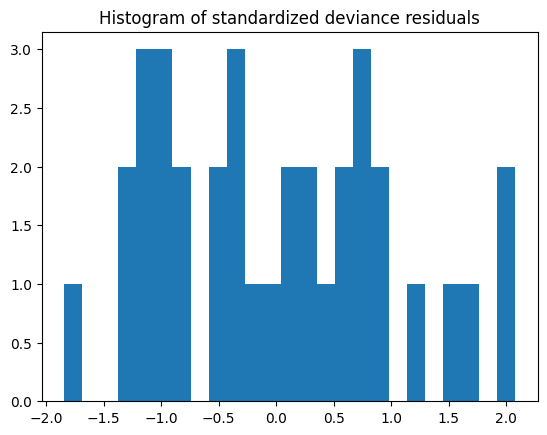

In [ ]:
from scipy import stats
fig, ax = plt.subplots()

resid = glm_results.resid_deviance.copy()
resid_std = stats.zscore(resid)
ax.hist(resid_std, bins=25)
ax.set_title('Histogram of standardized deviance residuals')